# Colorizer

Paper: https://arxiv.org/pdf/1603.08511

In [1]:
import sys
!{sys.executable} -m pip install torch torchvision --index-url https://download.pytorch.org/whl/cu132
!{sys.executable} -m pip install scikit-image tqdm matplotlib kornia

Looking in indexes: https://download.pytorch.org/whl/cu132



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import os
import time

import kornia
import skimage
import numpy as np
import torch
import torch.nn as nn
import torchvision
import matplotlib.pyplot as plt
from IPython.display import clear_output
from torch import Tensor
from torch.utils.data import DataLoader, Subset
from tqdm import tqdm

In [3]:
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"

In [14]:
PICTURE_SIZE = 256

PREPROCESSING_BATCH_SIZE = 32

TRAINING_EPOCHS = 10
TRAINING_BATCH_SIZE = 20

OUT_DIR = "out"
DATASET_DIR = "data"

In [5]:
os.makedirs(OUT_DIR, exist_ok=True)

In [6]:
def get_device():
    if torch.cuda.is_available():
        return torch.device("cuda")
    elif torch.backends.mps.is_available():
        return torch.device("mps")
    else:
        return torch.device("cpu")


device = get_device()
print(f"Using device: {device}")

Using device: cuda


## Centroids

Generated 141 in-gamut centroids.
Centroid shape: (141, 2)
Sample centroids (a, b):
[[ 20 -70]
 [ 30 -70]
 [ 40 -70]
 [ 50 -70]
 [ 60 -70]
 [ 70 -70]
 [ 80 -70]
 [ 20 -60]
 [ 30 -60]
 [ 40 -60]]


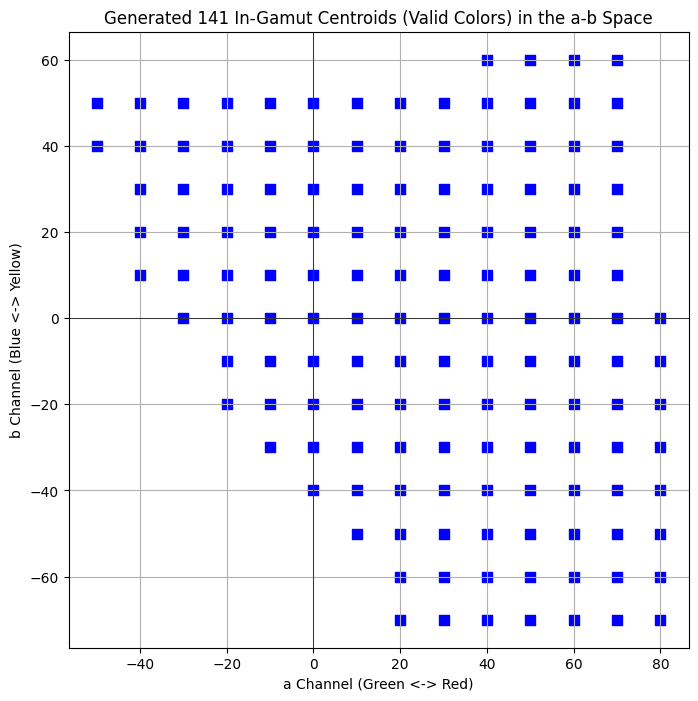

In [7]:
def generate_ab_centroids(step=10, cache=False):
    """
    Generate the centroids of the quantized a-b color space that are within the RGB gamut.
    The operation is very fast, the cache is not really needed.
    """

    save_dir = os.path.join(OUT_DIR, "pts_in_hull.npy")
    if cache and os.path.exists(save_dir):
        print(f"Loading cached centroids from {save_dir}")
        return np.load(save_dir)

    # Create a full 2D grid of a and b values
    a_vals = np.arange(-110, 120, step)
    b_vals = np.arange(-110, 120, step)
    a_grid, b_grid = np.meshgrid(a_vals, b_vals)

    # Build a "fake" image matrix (Height x Width x Channels)
    lab_pixels = np.zeros((a_grid.shape[0], a_grid.shape[1], 3))
    lab_pixels[:, :, 0] = 50.0  # L channel
    lab_pixels[:, :, 1] = a_grid
    lab_pixels[:, :, 2] = b_grid

    # 1. Convert to RGB (skimage clips out-of-gamut values to [0, 1] here)
    rgb_pixels = skimage.color.lab2rgb(lab_pixels)

    # 2. Convert back to Lab to see if the colors survived the conversion
    lab_reconstructed = skimage.color.rgb2lab(rgb_pixels)

    # 3. Calculate the Euclidean distance (Delta E) between original and reconstructed
    delta = np.linalg.norm(lab_pixels - lab_reconstructed, axis=-1)

    # If the delta is large, the color was clipped (out of gamut).
    # We use < 1.0 to allow for tiny floating-point rounding errors.
    valid_mask = delta < 1.0

    # Extract the valid a and b coordinates based on the mask
    valid_a = a_grid[valid_mask]
    valid_b = b_grid[valid_mask]

    # Combine them into the final (N, 2) array
    result = np.column_stack((valid_a, valid_b))

    np.save(save_dir, result)
    return result


centroids = generate_ab_centroids()
centroids_count = len(centroids)
print(f"Generated {centroids_count} in-gamut centroids.")
print(f"Centroid shape: {centroids.shape}")
print("Sample centroids (a, b):")
print(centroids[:10])  # Print the first 10 centroids as a sample

plt.figure(figsize=(8, 8))
plt.scatter(centroids[:, 0], centroids[:, 1], c="blue", marker="s", s=50)
plt.title(
    f"Generated {centroids_count} In-Gamut Centroids (Valid Colors) in the a-b Space"
)
plt.xlabel("a Channel (Green <-> Red)")
plt.ylabel("b Channel (Blue <-> Yellow)")
plt.grid(True)
plt.axhline(0, color="black", linewidth=0.5)
plt.axvline(0, color="black", linewidth=0.5)
plt.show()

## Dataset preparation

In [8]:
class IndexedImagenette(torchvision.datasets.Imagenette):
    """
    Wrapper around torchvision's Imagenette dataset to also return the index of each image, which is useful for caching precomputed results.
    """

    def __getitem__(self, index):
        img, target = super().__getitem__(index)
        return img, target, index


def precompute_dataset(ab_bins_tensor: Tensor, split="train"):
    save_dir = os.path.join(OUT_DIR, "precomputed_imagenette", split)
    os.makedirs(save_dir, exist_ok=True)

    # Transformation pipeline: ToTensor() converts the image to [C, H, W] in the range [0.0, 1.0]
    transform = torchvision.transforms.Compose(
        [
            torchvision.transforms.Resize((PICTURE_SIZE, PICTURE_SIZE)),
            torchvision.transforms.ToTensor(),
        ]
    )

    base_dataset = IndexedImagenette(
        root=DATASET_DIR, split=split, download=True, transform=transform
    )

    # Pre-filtering: find only the indices of images that haven't been computed yet
    unprocessed_indices = [
        idx
        for idx in range(len(base_dataset))
        if not os.path.exists(os.path.join(save_dir, f"img_{idx}.pt"))
    ]

    if not unprocessed_indices:
        print(f"All images for the '{split}' set have already been computed!")
        return

    subset = Subset(base_dataset, unprocessed_indices)

    # DataLoader to load images in parallel batches
    dataloader = DataLoader(
        subset,
        batch_size=PREPROCESSING_BATCH_SIZE,
        shuffle=False,
        num_workers=0,
        pin_memory=True,
    )

    print(
        f"Starting pre-computation for the {split} set: {len(unprocessed_indices)} images remaining out of {len(base_dataset)}"
    )

    # Disabling gradients to speed up and save VRAM
    with torch.no_grad():
        for imgs, _, indices in tqdm(dataloader):
            imgs = imgs.to(device)

            # Convert from RGB to LAB entirely on GPU using Kornia
            # Returns a LAB tensor where L is in [0, 100] and a,b are in [-128, 128]
            lab_batch = kornia.color.rgb_to_lab(imgs)

            # Extract and normalize L to [-1, 1]
            L = lab_batch[:, 0:1, :, :]  # Shape: (B, 1, H, W)
            L_norm = (L / 50.0) - 1.0

            # Extract ab and calculate centroids for the entire batch
            ab = lab_batch[:, 1:3, :, :]  # Shape: (B, 2, H, W)
            B, C, H, W = ab.shape

            # Flatten 'ab' to calculate distances for all pixels in the batch at once
            ab_flat = ab.permute(0, 2, 3, 1).reshape(B * H * W, 2)

            distances = torch.cdist(ab_flat, ab_bins_tensor)
            nearest_bins = torch.argmin(distances, dim=1)
            target_batch = nearest_bins.view(B, H, W).long()  # Returns a (B, H, W)

            # Move the results to CPU for saving
            L_norm_cpu = L_norm.cpu()
            target_batch_cpu = target_batch.cpu()

            # Save the results for each image in the batch
            for i in range(B):
                idx = indices[i].item()
                save_path = os.path.join(save_dir, f"img_{idx}.pt")
                torch.save((L_norm_cpu[i], target_batch_cpu[i]), save_path)


precompute_dataset(
    split="train",
    ab_bins_tensor=torch.tensor(centroids, dtype=torch.float32, device=device),
)

Starting pre-computation for the train set: 9469 images remaining out of 9469


100%|██████████| 296/296 [03:52<00:00,  1.27it/s]


In [9]:
class PrecomputedColorizationDataset(torch.utils.data.Dataset):
    def __init__(self, data_dir):
        """
        Loads the precomputed tensors directly from the .pt files saved previously.
        """
        self.data_dir = data_dir
        self.files = [f for f in os.listdir(data_dir) if f.endswith(".pt")]

        if len(self.files) == 0:
            raise RuntimeError(
                f"No .pt files found in {data_dir}. Did you run the precompute script?"
            )

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        file_path = os.path.join(self.data_dir, self.files[idx])
        L_tensor, target_tensor = torch.load(file_path)
        return L_tensor, target_tensor

## Training

In [12]:
class ColorfulImageColorizationNet(nn.Module):
    def __init__(self):
        super().__init__()

        # Conv1: 2 layers, spatial downsampling at the last layer, followed by BatchNorm
        self.conv1 = nn.Sequential(
            nn.Conv2d(1, 64, kernel_size=3, stride=1, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, stride=2, padding=1),  # Downsampling
            nn.ReLU(inplace=True),
            nn.BatchNorm2d(64),
        )

        # Conv2: 2 layers, spatial downsampling at the last layer
        self.conv2 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, stride=2, padding=1),  # Downsampling
            nn.ReLU(inplace=True),
            nn.BatchNorm2d(128),
        )

        # Conv3: 3 layers, spatial downsampling at the last layer
        self.conv3 = nn.Sequential(
            nn.Conv2d(128, 256, kernel_size=3, stride=1, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, stride=1, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, stride=2, padding=1),  # Downsampling
            nn.ReLU(inplace=True),
            nn.BatchNorm2d(256),
        )

        # Conv4: 3 layers, no downsampling
        self.conv4 = nn.Sequential(
            nn.Conv2d(256, 512, kernel_size=3, stride=1, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, stride=1, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, stride=1, padding=1),
            nn.ReLU(inplace=True),
            nn.BatchNorm2d(512),
        )

        # Conv5: 3 layers with dilated convolutions (à trous) with dilation=2
        self.conv5 = nn.Sequential(
            nn.Conv2d(512, 512, kernel_size=3, stride=1, padding=2, dilation=2),
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, stride=1, padding=2, dilation=2),
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, stride=1, padding=2, dilation=2),
            nn.ReLU(inplace=True),
            nn.BatchNorm2d(512),
        )

        # Conv6: 3 layers with dilated convolutions (à trous) with dilation=2
        self.conv6 = nn.Sequential(
            nn.Conv2d(512, 512, kernel_size=3, stride=1, padding=2, dilation=2),
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, stride=1, padding=2, dilation=2),
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, stride=1, padding=2, dilation=2),
            nn.ReLU(inplace=True),
            nn.BatchNorm2d(512),
        )

        # Conv7: 3 layers, no downsampling
        self.conv7 = nn.Sequential(
            nn.Conv2d(512, 256, kernel_size=3, stride=1, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, stride=1, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, stride=1, padding=1),
            nn.ReLU(inplace=True),
            nn.BatchNorm2d(256),
        )

        # Conv8: spatial upsampling at the beginning of the block
        self.conv8 = nn.Sequential(
            nn.ConvTranspose2d(
                256, 128, kernel_size=4, stride=2, padding=1
            ),  # Upsampling
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, stride=1, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, stride=1, padding=1),
            nn.ReLU(inplace=True),
            nn.BatchNorm2d(128),
        )

        # Final layer: maps the feature map to centroids_count quantized values
        self.conv_out = nn.Conv2d(
            128, centroids_count, kernel_size=1, stride=1, padding=0
        )

        # Bilinear upsampling to restore the output to the original size (e.g., 256x256)
        self.upsample = nn.Upsample(
            scale_factor=4, mode="bilinear", align_corners=False
        )

    def forward(self, x):
        # x is the lightness channel L
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = self.conv4(x)
        x = self.conv5(x)
        x = self.conv6(x)
        x = self.conv7(x)
        x = self.conv8(x)

        # Logits of the probability distribution over the centroids_count colors
        x = self.conv_out(x)

        # Final upsampling implemented as a feed-forward layer
        x = self.upsample(x)

        return x

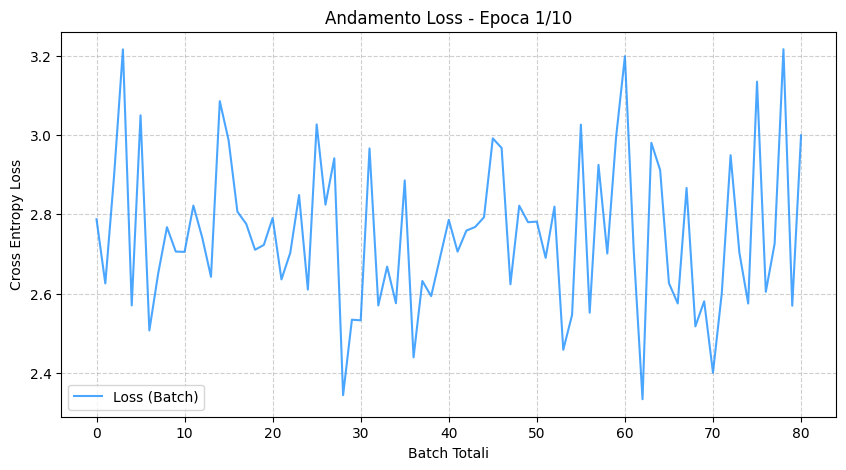

Epoch [1/10]:  21%|██        | 99/474 [00:41<02:37,  2.39it/s, loss=2.75]


KeyboardInterrupt: 

In [15]:
def train_model(from_checkpoint: str = None):
    # Deallocation of GPU memory before starting training to avoid fragmentation issues
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    # Inizializza modello e dataset
    model = ColorfulImageColorizationNet().to(device)
    train_dataset = PrecomputedColorizationDataset(
        data_dir=os.path.join(OUT_DIR, "precomputed_imagenette", "train")
    )
    train_loader = torch.utils.data.DataLoader(
        train_dataset,
        batch_size=TRAINING_BATCH_SIZE,
        shuffle=True,
        num_workers=0,
        pin_memory=True,
    )

    # Loss function: Cross Entropy Multinomiale [cite: 173]
    # nn.CrossEntropyLoss in PyTorch calcola in automatico la Softmax internamente.
    criterion = nn.CrossEntropyLoss()

    # Ottimizzatore: Il paper usa ADAM[cite: 236].
    # Parametri specifici dal paper: lr=3e-5, beta1=0.9, beta2=0.99, weight_decay=1e-3[cite: 238].
    optimizer = torch.optim.Adam(
        model.parameters(), lr=3e-5, betas=(0.9, 0.99), weight_decay=1e-3
    )

    # Setup loss chart
    plt.ion()  # Enables interactive mode in matplotlib
    fig, ax = plt.subplots(figsize=(10, 5))
    batch_losses = []

    if from_checkpoint is not None:
        print(f"Loading model weights from checkpoint: {from_checkpoint}")
        model.load_state_dict(
            torch.load(
                os.path.join(
                    OUT_DIR,
                    "model",
                    f"colorization_model_imagenette_epoch_{from_checkpoint}.pth",
                ),
                map_location=device,
            )
        )
        print("Checkpoint loaded successfully. Resuming training...")

    print("Inizio addestramento...")
    for epoch in range(TRAINING_EPOCHS):
        model.train()
        running_loss = 0.0

        loop = tqdm(
            train_loader, desc=f"Epoch [{epoch + 1}/{TRAINING_EPOCHS}]", leave=True
        )
        for batch_idx, (L_inputs, ab_targets) in enumerate(loop):
            L_inputs = L_inputs.to(device)
            ab_targets = ab_targets.to(device)  # Forma: (batch, 224, 224)

            # Azzera i gradienti
            optimizer.zero_grad()

            # Forward pass: logit predetti (batch, centroids_count, 224, 224)
            outputs = model(L_inputs)

            # Calcolo della loss. PyTorch accetta output (N, C, H, W) e target (N, H, W)
            loss = criterion(outputs, ab_targets)

            # Backward pass e ottimizzazione
            loss.backward()
            optimizer.step()

            # Update and show stats
            current_loss = loss.item()
            running_loss += current_loss
            batch_losses.append(current_loss)

            loop.set_postfix(loss=current_loss)

            # Aggiorna update the loss chart every 20 batches
            if batch_idx % 20 == 0:
                ax.clear()
                ax.plot(
                    batch_losses, label="Loss (Batch)", color="dodgerblue", alpha=0.8
                )
                ax.set_title(f"Andamento Loss - Epoca {epoch + 1}/{TRAINING_EPOCHS}")
                ax.set_xlabel("Batch Totali")
                ax.set_ylabel("Cross Entropy Loss")
                ax.grid(True, linestyle="--", alpha=0.6)
                ax.legend()

                clear_output(wait=True)
                display(fig)

                plt.pause(0.01)

        epoch_loss = running_loss / len(train_loader)
        print(f"--- Fine Epoca {epoch + 1} | Loss media: {epoch_loss:.4f} ---")

        # Save the model checkpoint at the end of each epoch
        torch.save(
            model.state_dict(),
            os.path.join(
                OUT_DIR, "model", f"colorization_model_imagenette_epoch_{epoch + 1}.pth"
            ),
        )

    print("Addestramento completato!")


train_model(from_checkpoint="8")

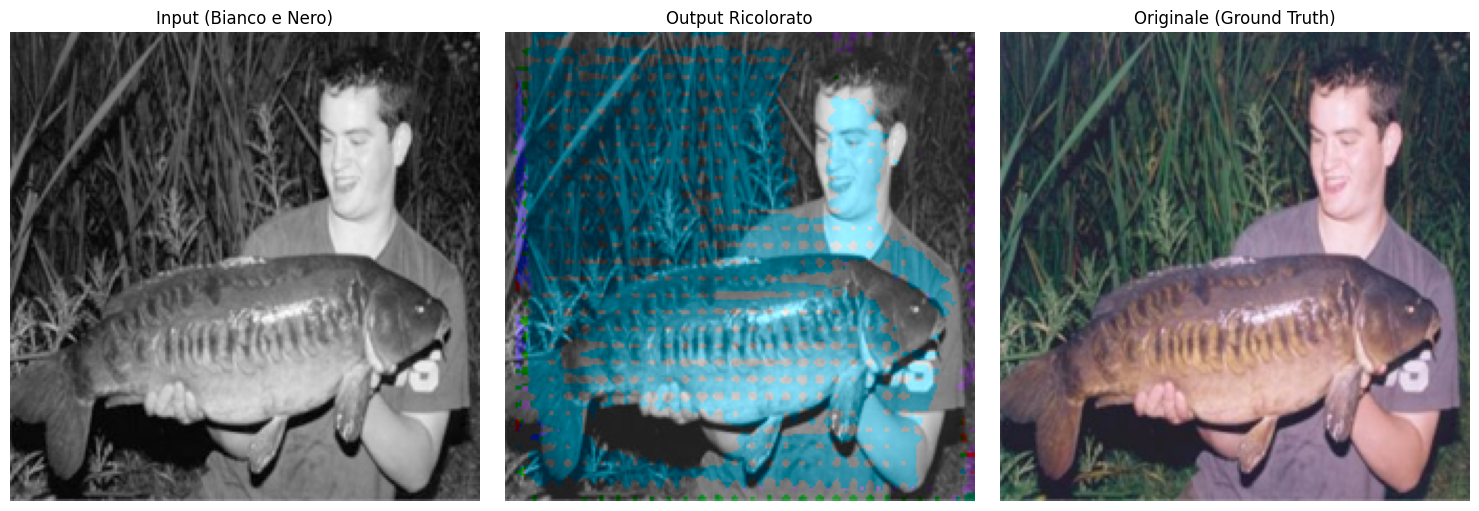

In [18]:
import torch
import torchvision.datasets as datasets
import numpy as np
import matplotlib.pyplot as plt
from skimage.color import rgb2lab, lab2rgb

# TODO: Assicurati di importare/definire la classe del tuo modello qui
# from tuo_modulo import ColorfulImageColorizationNet 

def colorize_imagenette_sample(model_path, centroids_path, image_index=0):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    # 1. Inizializza e carica il modello
    model = ColorfulImageColorizationNet().to(device)
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.eval()
    
    # Carica i centroidi
    centroids = np.load(centroids_path)
    
    # 2. Carica il dataset Imagenette (usiamo il validation set)
    # Se non è già scaricato, download=True lo scaricherà in './data'
    val_dataset = datasets.Imagenette(root='./data', split='val', download=True)
    
    # Estrai l'immagine e ignoriamo l'etichetta di classificazione
    img_pil, _ = val_dataset[image_index]
    
    # 3. Preprocessing dell'immagine
    img_resized = img_pil.convert("RGB").resize((224, 224))
    img_np = np.array(img_resized)
    
    # Convertiamo in LAB ed estraiamo il canale L
    img_lab = rgb2lab(img_np)
    L_channel = img_lab[:, :, 0]
    
    # Prepariamo il tensore (N, C, H, W)
    # Ricorda: applica qui la stessa normalizzazione usata nel tuo PrecomputedColorizationDataset
    L_tensor = torch.Tensor(L_channel).unsqueeze(0).unsqueeze(0).to(device)
    
    # 4. Forward Pass (Inferenza)
    with torch.no_grad():
        outputs = model(L_tensor)
        
    # 5. Postprocessing
    # Estraiamo gli indici predetti e li mappiamo ai valori 'ab'
    pred_indices = torch.argmax(outputs, dim=1).squeeze().cpu().numpy()
    pred_ab = centroids[pred_indices]
    
    # Ricostruiamo l'immagine
    out_lab = np.zeros((224, 224, 3))
    out_lab[:, :, 0] = L_channel
    out_lab[:, :, 1:] = pred_ab
    
    # Convertiamo in RGB
    out_rgb = lab2rgb(out_lab)
    
    # 6. Visualizzazione a tre pannelli
    fig, ax = plt.subplots(1, 3, figsize=(15, 5))
    
    # Pannello 1: Input Bianco e Nero
    ax[0].imshow(L_channel, cmap='gray')
    ax[0].set_title("Input (Bianco e Nero)")
    ax[0].axis('off')
    
    # Pannello 2: Output del Modello
    ax[1].imshow(out_rgb)
    ax[1].set_title("Output Ricolorato")
    ax[1].axis('off')
    
    # Pannello 3: Originale
    ax[2].imshow(img_np)
    ax[2].set_title("Originale (Ground Truth)")
    ax[2].axis('off')
    
    plt.tight_layout()
    plt.show()

# Esecuzione della simulazione sulla prima immagine del validation set
# Sostituisci i percorsi con quelli reali dei tuoi file
colorize_imagenette_sample(
    model_path="out/model/colorization_model_imagenette_epoch_8.pth", 
    centroids_path="out/pts_in_hull.npy",
    image_index=29 # Cambia questo numero per testare altre immagini (es. 10, 42, 100)
)